# Exploratory Data Analysis

In [8]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import ks_2samp

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 120)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")

RANDOM_STATE = 21352822
DAYS_SENTINEL = 365243

METADATA_COLUMNS = {"SK_ID_CURR", "SK_ID_PREV", "SK_ID_BUREAU", "TRAGET", "FOLD"}

AUXILIARY_SAMPLE_ROWS = 25000

DATA_DIR = Path("../data/raw")

print("DATA_DIR:", DATA_DIR.resolve())

DATA_DIR: /Users/ethan/Code Repository/MSDM 5054/Project/Project 1/data/raw


In [9]:
MODELING_FILES = {
    "application_train": "application_train.csv",
    "application_test": "application_test.csv",
    "bureau": "bureau.csv",
    "bureau_balance": "bureau_balance.csv",
    "previous_application": "previous_application.csv",
    "POS_CASH_balance": "POS_CASH_balance.csv",
    "credit_card_balance": "credit_card_balance.csv",
    "installments_payments": "installments_payments.csv",
}

OTHER_FILES = {
    "column_description": "HomeCredit_columns_description.csv",
    "sample_submission": "sample_submission.csv",
}

all_expected = list(MODELING_FILES.values()) + list(OTHER_FILES.values())

availability = pd.DataFrame({
    "file": all_expected,
    "exists": [(DATA_DIR / file).exists() for file in all_expected]
})

availability

,file,exists
0,application_train.csv,True
1,application_test.csv,True
2,bureau.csv,True
3,bureau_balance.csv,True
4,previous_application.csv,True
5,POS_CASH_balance.csv,True
6,credit_card_balance.csv,True
7,installments_payments.csv,True
8,HomeCredit_columns_description.csv,True
9,sample_submission.csv,True


In [10]:
# missing_files = availability.loc[~availability["exists"], "file"].tolist()
missing_modeling_files = {
    filename for filename in MODELING_FILES.values()
    if not (DATA_DIR / filename).exists()
}
missing_optional_files = {
    filename for filename in OTHER_FILES.values()
    if not (DATA_DIR / filename).exists()
}

# if missing_files:
#     print("Missing Files:")
#     for file in missing_files:
#         print(" -", file)
#     print("\nUpdate DATA_DIR before continuing. ")
# else:
#     print("All expected files were found. ")

if missing_modeling_files:
    formatted = "\n".join(f"- {name}" for name in missing_modeling_files)
    raise FileNotFoundError(
        "Required modeling files are missing from DATA_DIR: \n"
        f"{formatted}\n"
    )

if missing_optional_files:
    print("Optional files not found:", missing_optional_files)
else:
    print("All expected files were found.")

All expected files were found.


# 1. Load the Main Application Data

In [11]:
app_train = pd.read_csv(DATA_DIR / MODELING_FILES["application_train"])
app_test = pd.read_csv(DATA_DIR / MODELING_FILES["application_test"])

print("application_train:", app_train.shape)
print("application_test:", app_test.shape)
print("TARGET values    :", sorted(app_train["TARGET"].dropna().unique()))

application_train: (307511, 122)
application_test: (48744, 121)
TARGET values    : [np.int64(0), np.int64(1)]


In [12]:
app_train.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0000,406597.5000,24700.5000,351000.0000,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.0188,-9461,-637,-3648.0000,-2120,NaN,1,1,0,1,1,0,Laborers,1.0000,2,2,WEDNESDAY,10,0,0,0,0,0,0,Business Entity Type 3,0.0830,0.2629,0.1394,0.0247,0.0369,0.9722,0.6192,0.0143,0.0000,0.0690,0.0833,0.1250,0.0369,0.0202,0.0190,0.0000,0.0000,0.0252,0.0383,0.9722,0.6341,0.0144,0.0000,0.0690,0.0833,0.1250,0.0377,0.0220,0.0198,0.0000,0.0000,0.0250,0.0369,0.9722,0.6243,0.0144,0.0000,0.0690,0.0833,0.1250,0.0375,0.0205,0.0193,0.0000,0.0000,reg oper account,block of flats,0.0149,"Stone, brick",No,2.0000,2.0000,2.0000,2.0000,-1134.0000,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000
1,100003,0,Cash loans,F,N,N,0,270000.0000,1293502.5000,35698.5000,1129500.0000,Family,State servant,Higher education,Married,House / apartment,0.0035,-16765,-1188,-1186.0000,-291,NaN,1,1,0,1,1,0,Core staff,2.0000,1,1,MONDAY,11,0,0,0,0,0,0,School,0.3113,0.6222,NaN,0.0959,0.0529,0.9851,0.7960,0.0605,0.0800,0.0345,0.2917,0.3333,0.0130,0.0773,0.0549,0.0039,0.0098,0.0924,0.0538,0.9851,0.8040,0.0497,0.0806,0.0345,0.2917,0.3333,0.0128,0.0790,0.0554,0.0000,0.0000,0.0968,0.0529,0.9851,0.7987,0.0608,0.0800,0.0345,0.2917,0.3333,0.0132,0.0787,0.0558,0.0039,0.0100,reg oper account,block of flats,0.0714,Block,No,1.0000,0.0000,1.0000,0.0000,-828.0000,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
2,100004,0,Revolving loans,M,Y,Y,0,67500.0000,135000.0000,6750.0000,135000.0000,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.0100,-19046,-225,-4260.0000,-2531,26.0000,1,1,1,1,1,0,Laborers,1.0000,2,2,MONDAY,9,0,0,0,0,0,0,Government,NaN,0.5559,0.

# 2. Dataset Overview

In [13]:
overview_row = []

for name, filename in {**MODELING_FILES, **OTHER_FILES}.items():
    path = DATA_DIR / filename

    if not path.exists():
        continue

    # print(f"Reading: {filename}")

    try:
        header = pd.read_csv(path, nrows=0)
    except UnicodeDecodeError:
        header = pd.read_csv(path, nrows=0, encoding="cp1252")

    overview_row.append({
        "dataset": name,
        "filename": filename,
        "n_columns": len(header.columns)
    })

file_overview = (pd.DataFrame(overview_row))

file_overview

,dataset,filename,n_columns
0,application_train,application_train.csv,122
1,application_test,application_test.csv,121
2,bureau,bureau.csv,17
3,bureau_balance,bureau_balance.csv,3
4,previous_application,previous_application.csv,37
5,POS_CASH_balance,POS_CASH_balance.csv,8
6,credit_card_balance,credit_card_balance.csv,23
7,installments_payments,installments_payments.csv,8
8,column_description,HomeCredit_columns_description.csv,5
9,sample_submission,sample_submission.csv,2


# 3. Table Key & Relationship

In [14]:
KEY_COLUMNS = ["SK_ID_CURR", "SK_ID_PREV", "SK_ID_BUREAU"]

relationship_rows = []

for name, filename in MODELING_FILES.items():
    path = DATA_DIR / filename
    if not path.exists():
        continue

    cols = pd.read_csv(path, nrows=0).columns.tolist()

    relationship_rows.append({
        "dataset": name,
        "SK_ID_CURR": "SK_ID_CURR" in cols,
        "SK_ID_PREV": "SK_ID_PREV" in cols,
        "SK_ID_BUREAU": "SK_ID_BUREAU" in cols,
    })

relationship_df = pd.DataFrame(relationship_rows)
relationship_df

,dataset,SK_ID_CURR,SK_ID_PREV,SK_ID_BUREAU
0,application_train,True,False,False
1,application_test,True,False,False
2,bureau,True,False,True
3,bureau_balance,False,False,True
4,previous_application,True,True,False
5,POS_CASH_balance,True,True,False
6,credit_card_balance,True,True,False
7,installments_payments,True,True,False


# 4. Application Data Audit

## 4.1 Shapes, IDs, and duplicate checks

In [15]:
train_ids = app_train["SK_ID_CURR"]
test_ids = app_test["SK_ID_CURR"]

application_id_audit = pd.Series({
    "train_rows": len(app_train),
    "test_rows": len(app_test),
    "train_null_ids": train_ids.isna().sum(),
    "test_null_ids": test_ids.isna().sum(),
    "train_unique_ids": train_ids.nunique(),
    "test_unique_ids": test_ids.nunique(),
    "train_duplicate_ids": train_ids.duplicated().sum(),
    "test_duplicate_ids": test_ids.duplicated().sum(),
    "train_test_id_overlap": len(set(train_ids) & set(test_ids)),
    "duplicated_train_rows": app_train.duplicated().sum(),
    "duplicated_test_rows": app_test.duplicated().sum()
})

display(application_id_audit.to_frame("value"))

,value
train_rows,307511
test_rows,48744
train_null_ids,0
test_null_ids,0
train_unique_ids,307511
test_unique_ids,48744
train_duplicate_ids,0
test_duplicate_ids,0
train_test_id_overlap,0
duplicated_train_rows,0


## 4.2 Column consistency between train and test

In [16]:
train_only_columns = sorted(set(app_train.columns) - set(app_test.columns))
test_only_columns = sorted(set(app_test.columns) - set(app_train.columns))

print("Train-only columns:", train_only_columns)
print("Test-only columns:", test_only_columns)

Train-only columns: ['TARGET']
Test-only columns: []


## 4.3 Data types

In [17]:
dtype_summary = pd.DataFrame({
    "dtype": app_train.dtypes.astype(str),
    "n_unique": app_train.nunique(dropna=True),
    "missing_rate": app_train.isna().mean(),
})

dtype_summary.head(20)

,dtype,n_unique,missing_rate
SK_ID_CURR,int64,307511,0.0000
TARGET,int64,2,0.0000
NAME_CONTRACT_TYPE,str,2,0.0000
CODE_GENDER,str,3,0.0000
FLAG_OWN_CAR,str,2,0.0000
FLAG_OWN_REALTY,str,2,0.0000
CNT_CHILDREN,int64,15,0.0000
AMT_INCOME_TOTAL,float64,2548,0.0000
AMT_CREDIT,float64,5603,0.0000
AMT_ANNUITY,float64,13672,0.0000


In [18]:
print("Dtype counts:")
display(app_train.dtypes.value_counts())

# Features shared by train and test
shared_columns = [
    col for col in app_test.columns
    if col in app_train.columns
]

feature_columns = [
    col for col in shared_columns
    if col not in METADATA_COLUMNS
]

categorical_feature_cols = (
    app_train[feature_columns]
    .select_dtypes(include=["object", "category", "string"])
    .columns
    .tolist()
)

numerical_feature_cols = (
    app_train[feature_columns]
    .select_dtypes(include=np.number)
    .columns
    .tolist()
)

print("Shared predictive features:", len(feature_columns))
print("Categorical features      :", len(categorical_feature_cols))
print("Numerical features        :", len(numerical_feature_cols))


Dtype counts:


float64    65
int64      41
str        16
Name: count, dtype: int64

Shared predictive features: 120
Categorical features      : 16
Numerical features        : 104


In [19]:
print("Numerical summary:")

app_train.select_dtypes(include=np.number).describe().T.head(30)

Numerical summary:


,count,mean,std,min,25%,50%,75%,max
SK_ID_CURR,307511.0000,278180.5186,102790.1753,100002.0000,189145.5000,278202.0000,367142.5000,456255.0000
TARGET,307511.0000,0.0807,0.2724,0.0000,0.0000,0.0000,0.0000,1.0000
CNT_CHILDREN,307511.0000,0.4171,0.7221,0.0000,0.0000,0.0000,1.0000,19.0000
AMT_INCOME_TOTAL,307511.0000,168797.9193,237123.1463,25650.0000,112500.0000,147150.0000,202500.0000,117000000.0000
AMT_CREDIT,307511.0000,599025.9997,402490.7770,45000.0000,270000.0000,513531.0000,808650.0000,4050000.0000
AMT_ANNUITY,307499.0000,27108.5739,14493.7373,1615.5000,16524.0000,24903.0000,34596.0000,258025.5000
AMT_GOODS_PRICE,307233.0000,538396.2074,369446.4605,40500.0000,238500.0000,450000.0000,679500.0000,4050000.0000
REGION_POPULATION_RELATIVE,307511.0000,0.0209,0.0138,0.0003,0.0100,0.0188,0.0287,0.0725
DAYS_BIRTH,307511.0000,-16036.9951,4363.9886,-25229.0000,-19682.0000,-15750.0000,-12413.0000,-7489.0000
DAYS_EMPLOYED,307511.0000,63815.0459,141275.7665,-17912.0000,-2760.0000,-1213.0000,-289.0000,365243.0000


In [20]:
print("Categorical summary:")

app_train.select_dtypes(include=["object", "category"]).describe().T

Categorical summary:


,count,unique,top,freq
NAME_CONTRACT_TYPE,307511,2,Cash loans,278232
CODE_GENDER,307511,3,F,202448
FLAG_OWN_CAR,307511,2,N,202924
FLAG_OWN_REALTY,307511,2,Y,213312
NAME_TYPE_SUITE,306219,7,Unaccompanied,248526
NAME_INCOME_TYPE,307511,8,Working,158774
NAME_EDUCATION_TYPE,307511,5,Secondary / secondary special,218391
NAME_FAMILY_STATUS,307511,6,Married,196432
NAME_HOUSING_TYPE,307511,6,House / apartment,272868
OCCUPATION_TYPE,211120,18,Laborers,55186


# 5. Traget Distribution

In [21]:
target_counts = app_train["TARGET"].value_counts().sort_index()
target_rates = app_train["TARGET"].value_counts(normalize=True).sort_index()

target_summary = pd.DataFrame({
    "count": target_counts,
    "proportion": target_rates
})

target_summary

,count,proportion
TARGET,,
0,282686,0.9193
1,24825,0.0807


<function matplotlib.pyplot.show(close=None, block=None)>

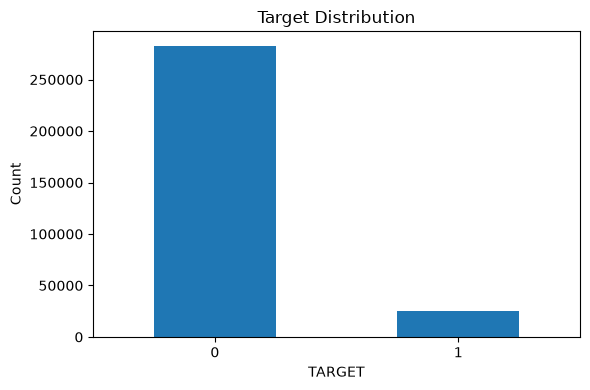

In [22]:
ax = target_counts.plot(kind="bar", figsize=(6,4))
ax.set_title("Target Distribution")
ax.set_xlabel("TARGET")
ax.set_ylabel("Count")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show

In [23]:
defaulat_rate = app_train["TARGET"].mean()

print(f"Default / repayment-difficulty rate: {defaulat_rate:.4%}")
print(f"Majority class proportion: {target_rates.max():.4%}")

Default / repayment-difficulty rate: 8.0729%
Majority class proportion: 91.9271%


# 6. Missing Value Audit

In [24]:
def missing_summary(df):
    result = pd.DataFrame({
        "dtype": df.dtypes.astype(str),
        "missing_count": df.isna().sum(),
        "missing_rate": df.isna().mean(),
        "n_unique": df.nunique(dropna=True)
    })

    return result.sort_values(
        ["missing_rate", "missing_count"],
        ascending=False
    )

app_missing = missing_summary(app_train)
app_missing.head(30)

,dtype,missing_count,missing_rate,n_unique
COMMONAREA_AVG,float64,214865,0.6987,3181
COMMONAREA_MODE,float64,214865,0.6987,3128
COMMONAREA_MEDI,float64,214865,0.6987,3202
NONLIVINGAPARTMENTS_AVG,float64,213514,0.6943,386
NONLIVINGAPARTMENTS_MODE,float64,213514,0.6943,167
NONLIVINGAPARTMENTS_MEDI,float64,213514,0.6943,214
FONDKAPREMONT_MODE,str,210295,0.6839,4
LIVINGAPARTMENTS_AVG,float64,210199,0.6835,1868
LIVINGAPARTMENTS_MODE,float64,210199,0.6835,736
LIVINGAPARTMENTS_MEDI,float64,210199,0.6835,1097


In [25]:
n_with_missing = (app_missing["missing_count"] > 0).sum()
n_over_30 = (app_missing["missing_rate"] > 0.30).sum()
n_over_50 = (app_missing["missing_rate"] > 0.50).sum()

print("Columns with any missing values:", n_with_missing)
print("Columns with > 30% missing:", n_over_30)
print("Columns with > 50% missing:", n_over_50)

Columns with any missing values: 67
Columns with > 30% missing: 50
Columns with > 50% missing: 41


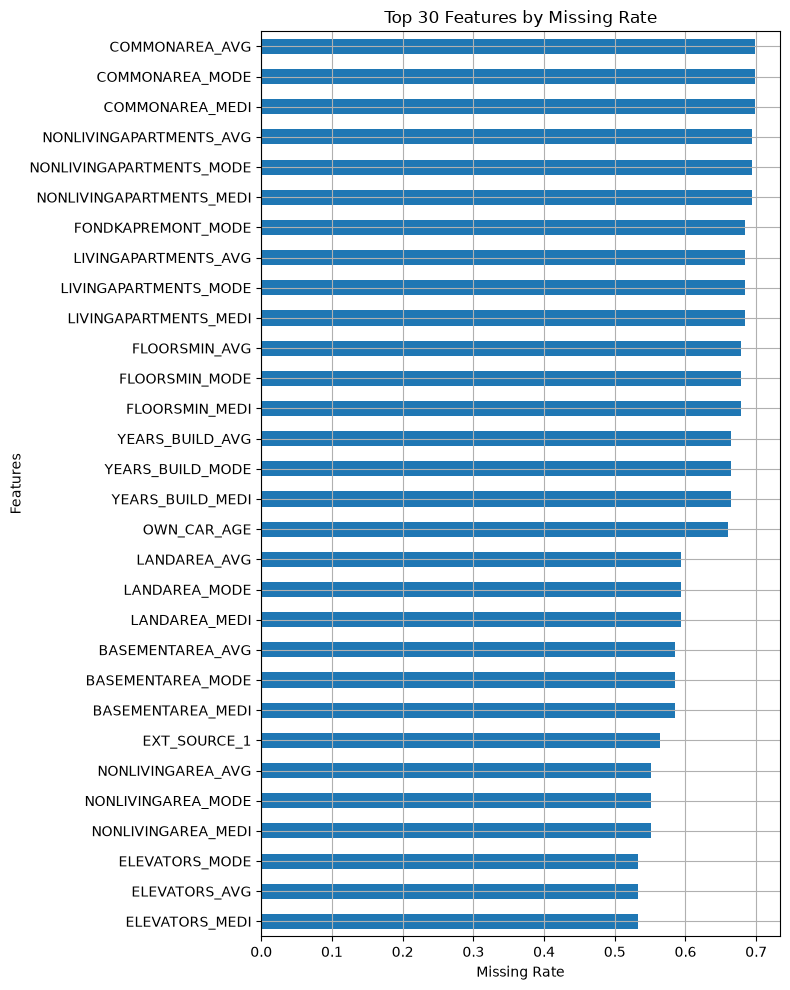

In [26]:
top_missing = (
    app_missing.query("missing_rate > 0").head(30).sort_values("missing_rate")
)

ax = top_missing["missing_rate"].plot(kind="barh", figsize=(8,10))
ax.set_title("Top 30 Features by Missing Rate")
ax.set_xlabel("Missing Rate")
ax.set_ylabel("Features")
plt.tight_layout()
plt.grid()
plt.show()

In [27]:
# Compare missing rates between TARGET = 0 and TARGET = 1
missing_target_0 = (
    app_train.loc[app_train["TARGET"] == 0, feature_columns]
    .isna()
    .mean()
)

missing_target_1 = (
    app_train.loc[app_train["TARGET"] == 1, feature_columns]
    .isna()
    .mean()
)

missing_target_audit = pd.DataFrame({
    "missing_rate_target_0": missing_target_0,
    "missing_rate_target_1": missing_target_1,
    "overall_missing_rate": app_train[feature_columns].isna().mean()
})

missing_target_audit["absolute_gap"] = (
    missing_target_audit["missing_rate_target_1"]
    - missing_target_audit["missing_rate_target_0"]
).abs()

missing_target_audit = missing_target_audit.sort_values(
    "absolute_gap",
    ascending=False
)

display(missing_target_audit.head(30))

,missing_rate_target_0,missing_rate_target_1,overall_missing_rate,absolute_gap
EMERGENCYSTATE_MODE,0.4679,0.5437,0.4740,0.0759
TOTALAREA_MODE,0.4766,0.5521,0.4827,0.0755
ENTRANCES_MEDI,0.4974,0.5724,0.5035,0.0750
ENTRANCES_MODE,0.4974,0.5724,0.5035,0.0750
ENTRANCES_AVG,0.4974,0.5724,0.5035,0.0750
FLOORSMAX_MODE,0.4916,0.5665,0.4976,0.0750
FLOORSMAX_AVG,0.4916,0.5665,0.4976,0.0750
FLOORSMAX_MEDI,0.4916,0.5665,0.4976,0.0750
YEARS_BEGINEXPLUATATION_AVG,0.4818,0.5562,0.4878,0.0744
YEARS_BEGINEXPLUATATION_MEDI,0.4818,0.5562,0.4878,0.0744


# 7. Abnormal and Suspicious Values

In [28]:
important_numeric = [
    "DAYS_BIRTH",
    "DAYS_EMPLOYED",
    "DAYS_REGISTRATION",
    "DAYS_ID_PUBLISH",
    "AMT_INCOME_TOTAL",
    "AMT_CREDIT",
    "AMT_ANNUITY",
    "AMT_GOODS_PRICE",
    "CNT_CHILDREN",
    "CNT_FAM_MEMBERS"
]

existing_important_numeric = [c for c in important_numeric if c in app_train.columns]

app_train[existing_important_numeric].describe(
    percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]
).T

,count,mean,std,min,1%,5%,50%,95%,99%,max
DAYS_BIRTH,307511.0000,-16036.9951,4363.9886,-25229.0000,-24419.0000,-23204.0000,-15750.0000,-9407.0000,-8263.0000,-7489.0000
DAYS_EMPLOYED,307511.0000,63815.0459,141275.7665,-17912.0000,-10894.9000,-6742.5000,-1213.0000,365243.0000,365243.0000,365243.0000
DAYS_REGISTRATION,307511.0000,-4986.1203,3522.8863,-24672.0000,-13879.0000,-11416.0000,-4504.0000,-330.0000,-50.0000,0.0000
DAYS_ID_PUBLISH,307511.0000,-2994.2024,1509.4504,-7197.0000,-5447.0000,-4944.0000,-3254.0000,-375.0000,-61.0000,0.0000
AMT_INCOME_TOTAL,307511.0000,168797.9193,237123.1463,25650.0000,45000.0000,67500.0000,147150.0000,337500.0000,472500.0000,117000000.0000
AMT_CREDIT,307511.0000,599025.9997,402490.7770,45000.0000,76410.0000,135000.0000,513531.0000,1350000.0000,1854000.0000,4050000.0000
AMT_ANNUITY,307499.0000,27108.5739,14493.7373,1615.5000,6182.9100,9000.0000,24903.0000,53325.0000,70006.5000,258025.5000
AMT_GOODS_PRICE,307233.0000,538396.2074,369446.4605,40500.0000,67500.0000,135000.0000,450000.0000,1305000.0000,1800000.0000,4050000.0000
CNT_CHILDREN,307511.0000,0.4171,0.7221,0.0000,0.0000,0.0000,0.0000,2.0000,3.0000,19.0000
CNT_FAM_MEMBERS,307509.0000,2.1527,0.9107,1.0000,1.0000,1.0000,2.0000,4.0000,5.0000,20.0000


In [29]:
for name, df in {"train": app_train, "test": app_test}.items():
    anomaly = df["DAYS_EMPLOYED"] == DAYS_SENTINEL

    print(
        f"{name}: {anomaly.sum():,} rows "
        f"({anomaly.mean():.4%}) have DAYS_EMPLOYED = {DAYS_SENTINEL}"
    )

display(
    app_train["DAYS_EMPLOYED"]
    .value_counts(dropna=False)
    .head(10)
    .to_frame("count")
)

train: 55,374 rows (18.0072%) have DAYS_EMPLOYED = 365243
test: 9,274 rows (19.0259%) have DAYS_EMPLOYED = 365243


,count
DAYS_EMPLOYED,
365243,55374
-200,156
-224,152
-199,151
-230,151
-212,150
-229,143
-384,143
-231,140


# 8. EDA

In [30]:
def clean_application_for_eda(df):
    out = df.copy()

    if "DAYS_EMPLOYED" in out.columns:
        out["DAYS_EMPLOYED_ANOM"] = out["DAYS_EMPLOYED"].eq(DAYS_SENTINEL).astype("int")
        out["DAYS_EMPLOYED"] = out["DAYS_EMPLOYED"].replace(DAYS_SENTINEL, np.nan)
        out["EMPLOYMENT_YEARS"] = -out["DAYS_EMPLOYED"] / 365.243

    if "DAYS_BIRTH" in out.columns:
        out["AGE_YEARS"] = -out["DAYS_BIRTH"] / 365.243

    return out

eda_train = clean_application_for_eda(app_train)
eda_test = clean_application_for_eda(app_test)

preview_cols = [
    c for c in ["AGE_YEARS", "EMPLOYMENT_YEARS", "DAYS_EMPLOYED_ANOM"]
    if c in eda_train
]
display(eda_train[preview_cols].describe().T)

,count,mean,std,min,25%,50%,75%,max
AGE_YEARS,307511.0000,43.9077,11.9482,20.5042,33.9856,43.1220,53.8874,69.0746
EMPLOYMENT_YEARS,252137.0000,6.5276,6.4022,-0.0000,2.1000,4.5121,8.6928,49.0413
DAYS_EMPLOYED_ANOM,307511.0000,0.1801,0.3842,0.0000,0.0000,0.0000,0.0000,1.0000


## 8.1 Numerical EDA

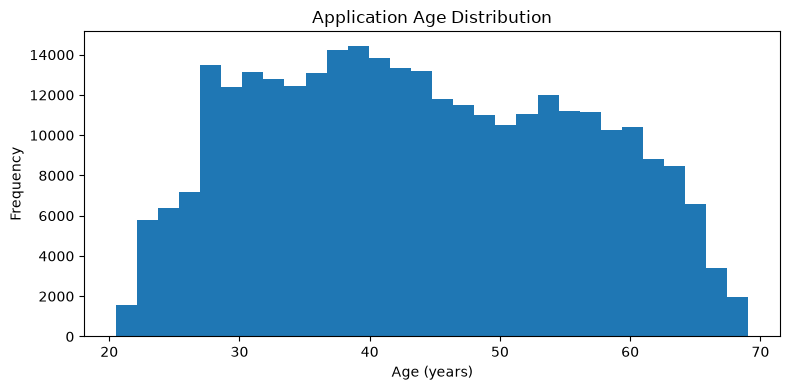

In [31]:
if "AGE_YEARS" in eda_train.columns:
    ax = eda_train["AGE_YEARS"].plot(
        kind="hist",
        bins=30,
        figsize=(8,4)
    )

    ax.set_title("Application Age Distribution")
    ax.set_xlabel("Age (years)")
    plt.tight_layout()
    plt.show()

In [32]:
if "AGE_YEARS" in eda_train.columns:
    age_bins = [20, 30, 40, 50, 60, 70, 100]

    age_target_summary = (
        eda_train.assign(
            AGE_GROUP=pd.cut(
                eda_train["AGE_YEARS"],
                bins=age_bins,
                right=False
            )
        )
        .groupby("AGE_GROUP", observed=False)["TARGET"]
        .agg(count="size", default_rate="mean")
    )

age_target_summary

,count,default_rate
AGE_GROUP,,
"[20, 30)",45186,0.1144
"[30, 40)",82331,0.0959
"[40, 50)",76599,0.0764
"[50, 60)",68094,0.0612
"[60, 70)",35301,0.0492
"[70, 100)",0,NaN


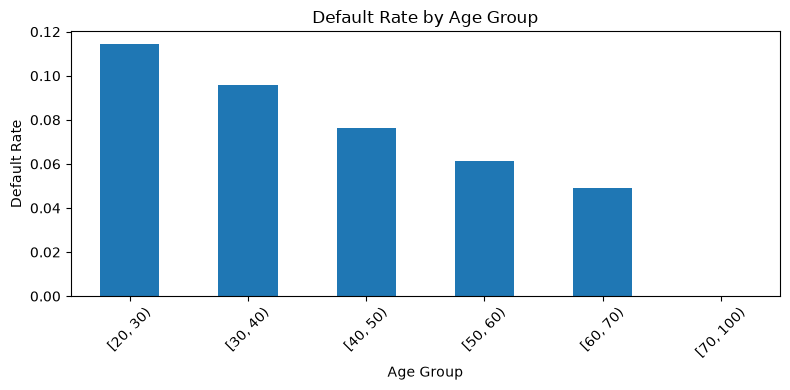

In [33]:
if "AGE_YEARS" in eda_train.columns:
    ax = age_target_summary["default_rate"].plot(
        kind="bar",
        figsize=(8,4)
    )

    ax.set_title("Default Rate by Age Group")
    ax.set_xlabel("Age Group")
    ax.set_ylabel("Default Rate")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

### 8.1.1 Income, credit, annuity and goods price

In [34]:
financial_cols = [
    "AMT_INCOME_TOTAL",
    "AMT_CREDIT",
    "AMT_ANNUITY",
    "AMT_GOODS_PRICE",
]

financial_cols = [c for c in financial_cols if c in eda_train.columns]

eda_train[financial_cols].describe(
    percentiles=[0.01, 0.05, 0.50, 0.95, 0.99]
).T

,count,mean,std,min,1%,5%,50%,95%,99%,max
AMT_INCOME_TOTAL,307511.0000,168797.9193,237123.1463,25650.0000,45000.0000,67500.0000,147150.0000,337500.0000,472500.0000,117000000.0000
AMT_CREDIT,307511.0000,599025.9997,402490.7770,45000.0000,76410.0000,135000.0000,513531.0000,1350000.0000,1854000.0000,4050000.0000
AMT_ANNUITY,307499.0000,27108.5739,14493.7373,1615.5000,6182.9100,9000.0000,24903.0000,53325.0000,70006.5000,258025.5000
AMT_GOODS_PRICE,307233.0000,538396.2074,369446.4605,40500.0000,67500.0000,135000.0000,450000.0000,1305000.0000,1800000.0000,4050000.0000


### 8.1.2 Numerical ranges and possible extreme values

In [35]:
robust_focus = [
    col
    for col in existing_important_numeric + [
        "EXT_SOURCE_1",
        "EXT_SOURCE_2",
        "EXT_SOURCE_3"
    ]
    if col in eda_train.columns and col not in METADATA_COLUMNS
]

numeric_range_rows = []

for col in robust_focus:
    values = pd.to_numeric(
        eda_train[col],
        errors="coerce"
    ).dropna()

    if len(values) == 0:
        continue

    q1 = values.quantile(0.25)
    q3 = values.quantile(0.75)
    iqr = q3 - q1

    lower = q1 - 3 * iqr
    upper = q3 + 3 * iqr

    extreme_rows = (
        (values < lower) | (values > upper)
    ).sum()

    numeric_range_rows.append({
        "feature": col,
        "non_null": len(values),
        "p1": values.quantile(0.01),
        "median": values.median(),
        "p99": values.quantile(0.99),
        "IQR": iqr,
        "extreme_rows_3IQR": extreme_rows,
        "extreme_rate_3IQR": extreme_rows / len(values)
    })

numeric_range_summary = pd.DataFrame(numeric_range_rows)
numeric_range_summary = numeric_range_summary.set_index("feature")
numeric_range_summary = numeric_range_summary.sort_values(
    "extreme_rate_3IQR",
    ascending=False
)

display(numeric_range_summary)


,non_null,p1,median,p99,IQR,extreme_rows_3IQR,extreme_rate_3IQR
feature,,,,,,,
DAYS_EMPLOYED,252137,-11338.2800,-1648.0000,-111.0000,2408.0000,3832,0.0152
AMT_INCOME_TOTAL,307511,45000.0000,147150.0000,472500.0000,90000.0000,3014,0.0098
AMT_GOODS_PRICE,307233,67500.0000,450000.0000,1800000.0000,441000.0000,1090,0.0035
AMT_ANNUITY,307499,6182.9100,24903.0000,70006.5000,18072.0000,1024,0.0033
AMT_CREDIT,307511,76410.0000,513531.0000,1854000.0000,538650.0000,444,0.0014
CNT_CHILDREN,307511,0.0000,0.0000,3.0000,1.0000,126,0.0004
CNT_FAM_MEMBERS,307509,1.0000,2.0000,5.0000,1.0000,121,0.0004
DAYS_REGISTRATION,307511,-13879.0000,-4504.0000,-50.0000,5469.5000,1,0.0000
DAYS_BIRTH,307511,-24419.0000,-15750.0000,-8263.0000,7269.0000,0,0.0000


### 8.1.3 Default rate across quantile bins

In [36]:
def numeric_target_by_quantile(df, column, q=10):
    temp = df[[column, "TARGET"]].dropna().copy()

    temp["bin"] = pd.qcut(
        temp[column],
        q=q,
        duplicates="drop"
    )

    return (
        temp
        .groupby("bin", observed=False)["TARGET"]
        .agg(count="size", default_rate="mean")
    )

for col in ["AMT_INCOME_TOTAL", "AMT_CREDIT", "AMT_ANNUITY"]:
    if col in eda_train.columns:
        print(f"\n{col}")
        display(numeric_target_by_quantile(eda_train, col, q=10))


AMT_INCOME_TOTAL


,count,default_rate
bin,,
"(25649.999, 81000.0]",33391,0.0819
"(81000.0, 99000.0]",30280,0.0822
"(99000.0, 112500.0]",36907,0.0872
"(112500.0, 135000.0]",48849,0.0849
"(135000.0, 147150.0]",4333,0.0900
"(147150.0, 162000.0]",31120,0.0864
"(162000.0, 180000.0]",30704,0.0842
"(180000.0, 225000.0]",44809,0.0781
"(225000.0, 270000.0]",19957,0.0704



AMT_CREDIT


,count,default_rate
bin,,
"(44999.999, 180000.0]",33204,0.0672
"(180000.0, 254700.0]",31721,0.0778
"(254700.0, 306306.0]",27391,0.0821
"(306306.0, 432000.0]",30707,0.1003
"(432000.0, 513531.0]",30826,0.0959
"(513531.0, 604152.0]",30726,0.1052
"(604152.0, 755190.0]",34066,0.0854
"(755190.0, 900000.0]",29958,0.0708
"(900000.0, 1133748.0]",28319,0.0688



AMT_ANNUITY


,count,default_rate
bin,,
"(1615.499, 11074.5]",30880,0.0710
"(11074.5, 14701.5]",30627,0.0679
"(14701.5, 18189.0]",30763,0.0848
"(18189.0, 21865.5]",30731,0.0869
"(21865.5, 24903.0]",30772,0.0848
"(24903.0, 28062.0]",30790,0.0911
"(28062.0, 32004.0]",30690,0.1008
"(32004.0, 37516.5]",30762,0.0860
"(37516.5, 45954.0]",30808,0.0762


### 8.1.4 External source scores

In [37]:
ext_cols = [
    c for c in ["EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3"]
    if c in eda_train.columns
]

if ext_cols:
    display(
        eda_train
        .groupby("TARGET")[ext_cols]
        .agg(["mean", "median", "count"])
    )

EXT_SOURCE_1                EXT_SOURCE_2                EXT_SOURCE_3  \
               mean median   count         mean median   count         mean   
TARGET                                                                        
0            0.5115 0.5175  124079       0.5235 0.5739  282078       0.5210   
1            0.3870 0.3617   10054       0.4109 0.4404   24773       0.3907   

                       
       median   count  
TARGET                 
0      0.5460  227398  
1      0.3791   19148

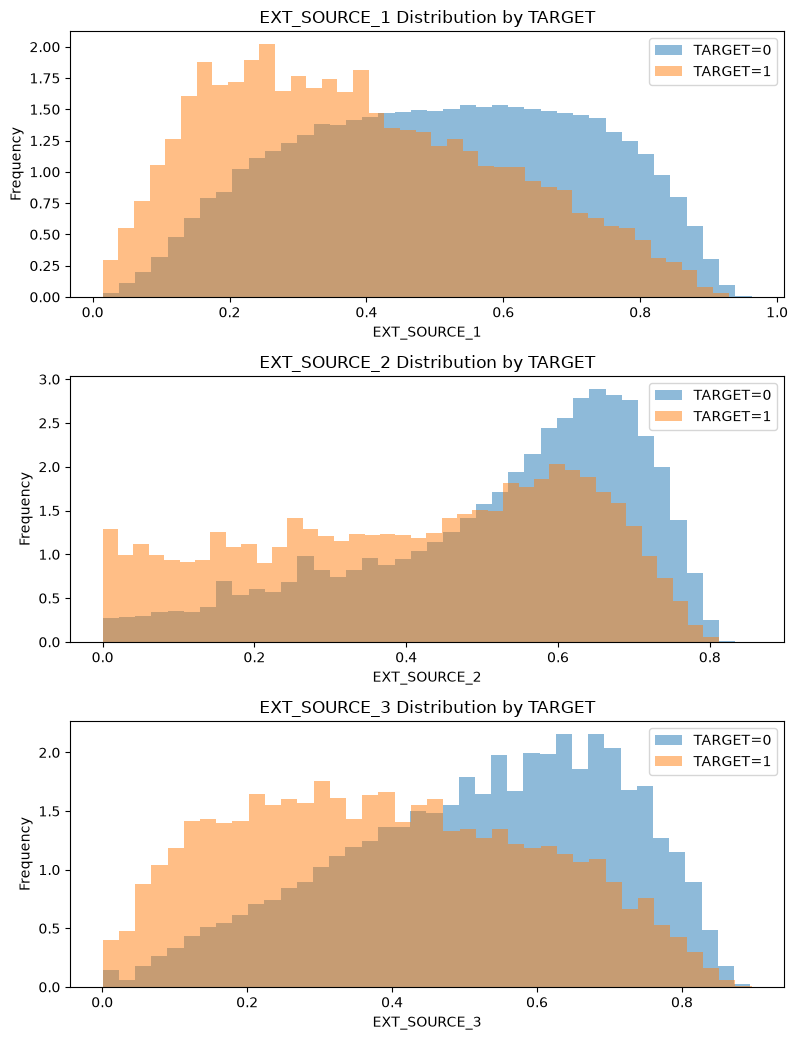

In [38]:
if ext_cols:
    fig, axes = plt.subplots(
        nrows=len(ext_cols),
        ncols=1,
        figsize=(8, 3.5 * len(ext_cols))
    )

    if len(ext_cols) == 1:
        axes = [axes]

    for ax, col in zip(axes, ext_cols):
        eda_train.loc[eda_train["TARGET"] == 0, col].dropna().plot(
            kind="hist",
            bins=40,
            alpha=0.5,
            density=True,
            ax=ax,
            label="TARGET=0"
        )
        eda_train.loc[eda_train["TARGET"] == 1, col].dropna().plot(
            kind="hist",
            bins=40,
            alpha=0.5,
            density=True,
            ax=ax,
            label="TARGET=1"
        )
        ax.set_title(f"{col} Distribution by TARGET")
        ax.set_xlabel(col)
        ax.legend()

    plt.tight_layout()
    plt.show()

### 8.1.5 Pearson correlation with TARGET

In [39]:
corr_features = [
    col
    for col in eda_train.select_dtypes(include=np.number).columns
    if col not in METADATA_COLUMNS
]

numeric_corr = (
    eda_train[corr_features]
    .corrwith(eda_train["TARGET"])
    .dropna()
    .sort_values()
)

print("Most negative correlations:")
display(
    numeric_corr
    .head(15)
    .to_frame("corr_with_TARGET")
)

print("\nMost positive correlations:")
display(
    numeric_corr
    .tail(15)
    .sort_values(ascending=False)
    .to_frame("corr_with_TARGET")
)

Most negative correlations:


,corr_with_TARGET
EXT_SOURCE_3,-0.1789
EXT_SOURCE_2,-0.1605
EXT_SOURCE_1,-0.1553
AGE_YEARS,-0.0782
EMPLOYMENT_YEARS,-0.0750
DAYS_EMPLOYED_ANOM,-0.0460
FLOORSMAX_AVG,-0.0440
FLOORSMAX_MEDI,-0.0438
FLOORSMAX_MODE,-0.0432
AMT_GOODS_PRICE,-0.0396



Most positive correlations:


,corr_with_TARGET
TARGET,1.0000
DAYS_BIRTH,0.0782
DAYS_EMPLOYED,0.0750
REGION_RATING_CLIENT_W_CITY,0.0609
REGION_RATING_CLIENT,0.0589
DAYS_LAST_PHONE_CHANGE,0.0552
DAYS_ID_PUBLISH,0.0515
REG_CITY_NOT_WORK_CITY,0.0510
FLAG_EMP_PHONE,0.0460
REG_CITY_NOT_LIVE_CITY,0.0444


### 8.1.6 Highly correlated numerical features

In [40]:
redundancy_columns = [
    col
    for col in numerical_feature_cols
    if col in eda_train.columns
]

corr_matrix = eda_train[redundancy_columns].corr().abs()

upper_triangle = corr_matrix.where(
    np.triu(
        np.ones(corr_matrix.shape),
        k=1
    ).astype(bool)
)

high_corr_pairs = (upper_triangle.stack().reset_index())

high_corr_pairs.columns = [
    "feature_a",
    "feature_b",
    "abs_pearson_corr"
]

high_corr_pairs = (high_corr_pairs[high_corr_pairs["abs_pearson_corr"] >= 0.90]
    .sort_values(
        "abs_pearson_corr",
        ascending=False
    )
)

display(high_corr_pairs.head(50))

,feature_a,feature_b,abs_pearson_corr
3493,YEARS_BUILD_AVG,YEARS_BUILD_MEDI,0.9985
7667,OBS_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,0.9985
4018,FLOORSMIN_AVG,FLOORSMIN_MEDI,0.9972
3913,FLOORSMAX_AVG,FLOORSMAX_MEDI,0.9970
3808,ENTRANCES_AVG,ENTRANCES_MEDI,0.9969
3703,ELEVATORS_AVG,ELEVATORS_MEDI,0.9961
3598,COMMONAREA_AVG,COMMONAREA_MEDI,0.9960
4333,LIVINGAREA_AVG,LIVINGAREA_MEDI,0.9956
3178,APARTMENTS_AVG,APARTMENTS_MEDI,0.9951
3283,BASEMENTAREA_AVG,BASEMENTAREA_MEDI,0.9943


## 8.2 Categorical EDA

In [41]:
def categorical_target_summary(df, column, min_count=200):
    summary = (
        df.groupby(column, dropna=False)["TARGET"]
        .agg(["count", "mean"])
        .rename(columns={"mean": "default_rate"})
    )

    summary["share"] = summary["count"] / len(df)
    summary["enough_rows"] = summary["count"] >= min_count

    return summary.sort_values(
        ["enough_rows", "default_rate", "count"],
        ascending=[False, False, False]
    )


categorical_focus = [
    "NAME_CONTRACT_TYPE",
    "CODE_GENDER",
    "FLAG_OWN_CAR",
    "FLAG_OWN_REALTY",
    "WEEKDAY_APPR_PROCESS_START",
    "NAME_INCOME_TYPE",
    "NAME_EDUCATION_TYPE",
    "NAME_FAMILY_STATUS",
    "NAME_HOUSING_TYPE",
    "OCCUPATION_TYPE",
    "ORGANIZATION_TYPE"
]

categorical_focus = [
    col for col in categorical_focus
    if col in categorical_feature_cols
]

for col in categorical_focus:
    print(f"\n### {col}")
    display(
        categorical_target_summary(
            eda_train,
            col,
            min_count=200
        ).head(30)
    )



### NAME_CONTRACT_TYPE


,count,default_rate,share,enough_rows
NAME_CONTRACT_TYPE,,,,
Cash loans,278232,0.0835,0.9048,True
Revolving loans,29279,0.0548,0.0952,True



### CODE_GENDER


,count,default_rate,share,enough_rows
CODE_GENDER,,,,
M,105059,0.1014,0.3416,True
F,202448,0.0700,0.6583,True
XNA,4,0.0000,0.0000,False



### FLAG_OWN_CAR


...

,count,default_rate,share,enough_rows
NAME_HOUSING_TYPE,,,,
Rented apartment,4881,0.1231,0.0159,True
With parents,14840,0.1170,0.0483,True
Municipal apartment,11183,0.0854,0.0364,True
Co-op apartment,1122,0.0793,0.0036,True
House / apartment,272868,0.0780,0.8873,True
Office apartment,2617,0.0657,0.0085,True



### OCCUPATION_TYPE


,count,default_rate,share,enough_rows
OCCUPATION_TYPE,,,,
Low-skill Laborers,2093,0.1715,0.0068,True
Drivers,18603,0.1133,0.0605,True
Waiters/barmen staff,1348,0.1128,0.0044,True
Security staff,6721,0.1074,0.0219,True
Laborers,55186,0.1058,0.1795,True
Cooking staff,5946,0.1044,0.0193,True
Sales staff,32102,0.0963,0.1044,True
Cleaning staff,4653,0.0961,0.0151,True
Realty agents,751,0.0786,0.0024,True



### ORGANIZATION_TYPE


,count,default_rate,share,enough_rows
ORGANIZATION_TYPE,,,,
Transport: type 3,1187,0.1575,0.0039,True
Restaurant,1811,0.1171,0.0059,True
Construction,6721,0.1168,0.0219,True
Cleaning,260,0.1115,0.0008,True
Industry: type 1,1039,0.1107,0.0034,True
Industry: type 3,3278,0.1062,0.0107,True
Realtor,396,0.1061,0.0013,True
Agriculture,2454,0.1047,0.0080,True
Trade: type 3,3492,0.1034,0.0114,True


### 8.2.1 Rare categories

In [42]:
rare_category_summary = []

for col in categorical_feature_cols:
    freq = app_train[col].value_counts(normalize=True, dropna=False)
    counts = app_train[col].value_counts(dropna=False)

    rare_category_summary.append({
        "feature": col,
        "n_categories": len(freq),
        "n_categories_below_1pct": int((freq < 0.01).sum()),
        "n_categories_below_200_rows": int((counts < 200).sum()),
        "smallest_category_count": int(counts.min()),
        "smallest_category_share": freq.min(),
    })

rare_category_df = (
    pd.DataFrame(rare_category_summary)
    .sort_values(["n_categories_below_200_rows", "n_categories"], ascending=False)
)

display(rare_category_df.head(30))

,feature,n_categories,n_categories_below_1pct,n_categories_below_200_rows,smallest_category_count,smallest_category_share
11,ORGANIZATION_TYPE,58,41,7,24,0.0001
5,NAME_INCOME_TYPE,8,4,4,5,0.0000
7,NAME_FAMILY_STATUS,6,1,1,2,0.0000
6,NAME_EDUCATION_TYPE,5,1,1,164,0.0005
1,CODE_GENDER,3,1,1,4,0.0000
9,OCCUPATION_TYPE,19,7,0,526,0.0017
4,NAME_TYPE_SUITE,8,4,0,271,0.0009
14,WALLSMATERIAL_MODE,8,3,0,1625,0.0053
10,WEEKDAY_APPR_PROCESS_START,7,0,0,16181,0.0526
8,NAME_HOUSING_TYPE,6,2,0,1122,0.0036


# 9. Train & Test Comparison

## 9.1 Categorical levels present only in test

In [43]:
categorical_test_only = []

for col in categorical_feature_cols:
    train_values = set(
        app_train[col]
        .dropna()
        .unique()
    )

    test_values = set(
        app_test[col]
        .dropna()
        .unique()
    )

    unseen = sorted(
        test_values - train_values,
        key=str
    )

    unseen_rows = app_test[col].isin(unseen).sum()

    categorical_test_only.append({
        "feature": col,
        "n_train_categories": len(train_values),
        "n_test_categories": len(test_values),
        "n_test_only_categories": len(unseen),
        "test_rows_in_unseen_categories": unseen_rows,
        "test_share_in_unseen_categories": unseen_rows / len(app_test),
        "test_only_categories": unseen
    })

categorical_test_only_df = pd.DataFrame(categorical_test_only)

if len(categorical_test_only_df) > 0:
    test_only_categories = categorical_test_only_df[
        categorical_test_only_df["n_test_only_categories"] > 0
    ]

    test_only_categories = test_only_categories.sort_values(
        "test_share_in_unseen_categories",
        ascending=False
    )

    display(test_only_categories)
else:
    print("No categorical features were found.")


,feature,n_train_categories,n_test_categories,n_test_only_categories,test_rows_in_unseen_categories,test_share_in_unseen_categories,test_only_categories


## 9.2 Train/test drift check

In [44]:
def calculate_psi(train_series, test_series, bins=10):
    train_values = train_series.replace(
        [np.inf, -np.inf],
        np.nan
    ).dropna()

    test_values = test_series.replace(
        [np.inf, -np.inf],
        np.nan
    ).dropna()

    if len(train_values) == 0 or len(test_values) == 0:
        return np.nan

    breakpoints = np.unique(
        np.quantile(
            train_values,
            np.linspace(0, 1, bins + 1)
        )
    )

    if len(breakpoints) < 3:
        return np.nan

    breakpoints[0] = -np.inf
    breakpoints[-1] = np.inf

    train_count = np.histogram(
        train_values,
        bins=breakpoints
    )[0]

    test_count = np.histogram(
        test_values,
        bins=breakpoints
    )[0]

    train_pct = train_count / train_count.sum()
    test_pct = test_count / test_count.sum()

    train_pct = np.where(train_pct == 0, 1e-6, train_pct)
    test_pct = np.where(test_pct == 0, 1e-6, test_pct)

    psi = np.sum(
        (test_pct - train_pct)
        * np.log(test_pct / train_pct)
    )

    return psi


shared_feature_columns = [
    col
    for col in feature_columns
    if col in eda_test.columns
]

missing_drift = pd.DataFrame({
    "train_missing_rate":
        eda_train[shared_feature_columns].isna().mean(),

    "test_missing_rate":
        eda_test[shared_feature_columns].isna().mean()
})

missing_drift["missing_rate_gap"] = (
    missing_drift["test_missing_rate"]
    - missing_drift["train_missing_rate"]
)

missing_drift["absolute_missing_rate_gap"] = (
    missing_drift["missing_rate_gap"].abs()
)

drift_numeric_columns = [
    "DAYS_BIRTH",
    "DAYS_EMPLOYED",
    "DAYS_REGISTRATION",
    "DAYS_ID_PUBLISH",
    "AMT_INCOME_TOTAL",
    "AMT_CREDIT",
    "AMT_ANNUITY",
    "AMT_GOODS_PRICE",
    "EXT_SOURCE_1",
    "EXT_SOURCE_2",
    "EXT_SOURCE_3"
]

drift_numeric_columns = [
    col for col in drift_numeric_columns
    if col in eda_train.columns
    and col in eda_test.columns
]

numerical_drift_rows = []

for col in drift_numeric_columns:
    train_values = eda_train[col].dropna()
    test_values = eda_test[col].dropna()

    ks_result = ks_2samp(
        train_values,
        test_values
    )

    numerical_drift_rows.append({
        "feature": col,
        "train_median": train_values.median(),
        "test_median": test_values.median(),
        "PSI": calculate_psi(
            train_values,
            test_values
        ),
        "KS": ks_result.statistic,
        "KS_pvalue": ks_result.pvalue
    })

numerical_drift = pd.DataFrame(
    numerical_drift_rows
).set_index("feature")

numerical_drift = numerical_drift.join(
    missing_drift[
        [
            "missing_rate_gap",
            "absolute_missing_rate_gap"
        ]
    ]
)

numerical_drift = numerical_drift.sort_values(
    ["PSI", "KS"],
    ascending=False
)

print("Largest train/test missing-rate gaps:")
display(
    missing_drift
    .sort_values(
        "absolute_missing_rate_gap",
        ascending=False
    )
    .head(30)
)

print("\nNumerical drift summary:")
display(numerical_drift)

Largest train/test missing-rate gaps:


,train_missing_rate,test_missing_rate,missing_rate_gap,absolute_missing_rate_gap
EXT_SOURCE_1,0.5638,0.4212,-0.1426,0.1426
EXT_SOURCE_3,0.1983,0.1778,-0.0204,0.0204
ENTRANCES_MEDI,0.5035,0.4837,-0.0198,0.0198
ENTRANCES_MODE,0.5035,0.4837,-0.0198,0.0198
ENTRANCES_AVG,0.5035,0.4837,-0.0198,0.0198
FLOORSMAX_MODE,0.4976,0.4784,-0.0192,0.0192
FLOORSMAX_AVG,0.4976,0.4784,-0.0192,0.0192
FLOORSMAX_MEDI,0.4976,0.4784,-0.0192,0.0192
YEARS_BEGINEXPLUATATION_AVG,0.4878,0.4689,-0.0189,0.0189
YEARS_BEGINEXPLUATATION_MEDI,0.4878,0.4689,-0.0189,0.0189



Numerical drift summary:


,train_median,test_median,PSI,KS,KS_pvalue,missing_rate_gap,absolute_missing_rate_gap
feature,,,,,,,
AMT_CREDIT,513531.0000,450000.0000,0.0798,0.1162,0.0000,0.0000,0.0000
AMT_GOODS_PRICE,450000.0000,396000.0000,0.0794,0.1128,0.0000,-0.0009,0.0009
DAYS_ID_PUBLISH,-3254.0000,-3234.0000,0.0669,0.0577,0.0000,0.0000,0.0000
AMT_ANNUITY,24903.0000,26199.0000,0.0336,0.0577,0.0000,0.0005,0.0005
AMT_INCOME_TOTAL,147150.0000,157500.0000,0.0203,0.0568,0.0000,0.0000,0.0000
EXT_SOURCE_2,0.5660,0.5588,0.0100,0.0234,0.0000,-0.0020,0.0020
DAYS_EMPLOYED,-1648.0000,-1765.0000,0.0087,0.0343,0.0000,0.0102,0.0102
EXT_SOURCE_3,0.5353,0.5191,0.0062,0.0330,0.0000,-0.0204,0.0204
EXT_SOURCE_1,0.5060,0.5068,0.0053,0.0172,0.0000,-0.1426,0.1426


# 10. Sample-Based Audit of Auxiliary Tables

In [45]:
AUXILIARY_KEYS = {
    "bureau": ["SK_ID_BUREAU"],
    "bureau_balance": ["SK_ID_BUREAU", "MONTHS_BALANCE"],
    "previous_application": ["SK_ID_PREV"],
    "POS_CASH_balance": ["SK_ID_PREV", "MONTHS_BALANCE"],
    "credit_card_balance": ["SK_ID_PREV", "MONTHS_BALANCE"],
    "installments_payments": [
        "SK_ID_PREV",
        "NUM_INSTALMENT_VERSION",
        "NUM_INSTALMENT_NUMBER"
    ]
}


In [46]:
auxiliary_overview = []
auxiliary_samples = {}

application_ids = set(
    pd.concat(
        [
            app_train["SK_ID_CURR"],
            app_test["SK_ID_CURR"]
        ]
    )
)

for name, key_columns in AUXILIARY_KEYS.items():
    path = DATA_DIR / MODELING_FILES[name]

    print(f"\n{name}")

    sample = pd.read_csv(
        path,
        nrows=AUXILIARY_SAMPLE_ROWS,
        low_memory=False
    )

    auxiliary_samples[name] = sample.head()

    key_null_rows = (
        sample[key_columns]
        .isna()
        .any(axis=1)
        .sum()
    )

    key_duplicate_rows = (
        sample[key_columns]
        .duplicated(keep=False)
        .sum()
    )

    result = {
        "dataset": name,
        "file_size_MB": path.stat().st_size / (1024 ** 2),
        "sample_rows": len(sample),
        "n_columns": sample.shape[1],
        "mean_missing_rate": sample.isna().mean().mean(),
        "key_columns": " + ".join(key_columns),
        "key_null_rows": key_null_rows,
        "key_duplicate_rows": key_duplicate_rows
    }

    if "SK_ID_CURR" in sample.columns:
        known_id_rate = (
            sample["SK_ID_CURR"]
            .isin(application_ids)
            .mean()
        )

        result["sample_SK_ID_CURR_match_rate"] = known_id_rate

    auxiliary_overview.append(result)

    print("Preview:")
    display(sample.head())

    print("Dtype counts:")
    display(
        sample.dtypes
        .astype(str)
        .value_counts()
        .to_frame("column_count")
    )

    print("Top missing rates:")
    display(
        sample.isna()
        .mean()
        .sort_values(ascending=False)
        .head(15)
        .to_frame("missing_rate")
    )



bureau
Preview:


,SK_ID_CURR,SK_ID_BUREAU,CREDIT_ACTIVE,CREDIT_CURRENCY,DAYS_CREDIT,CREDIT_DAY_OVERDUE,DAYS_CREDIT_ENDDATE,DAYS_ENDDATE_FACT,AMT_CREDIT_MAX_OVERDUE,CNT_CREDIT_PROLONG,AMT_CREDIT_SUM,AMT_CREDIT_SUM_DEBT,AMT_CREDIT_SUM_LIMIT,AMT_CREDIT_SUM_OVERDUE,CREDIT_TYPE,DAYS_CREDIT_UPDATE,AMT_ANNUITY
0,215354,5714462,Closed,currency 1,-497,0,-153.0000,-153.0000,NaN,0,91323.0000,0.0000,NaN,0.0000,Consumer credit,-131,NaN
1,215354,5714463,Active,currency 1,-208,0,1075.0000,NaN,NaN,0,225000.0000,171342.0000,NaN,0.0000,Credit card,-20,NaN
2,215354,5714464,Active,currency 1,-203,0,528.0000,NaN,NaN,0,464323.5000,NaN,NaN,0.0000,Consumer credit,-16,NaN
3,215354,5714465,Active,currency 1,-203,0,NaN,NaN,NaN,0,90000.0000,NaN,NaN,0.0000,Credit card,-16,NaN
4,215354,5714466,Active,currency 1,-629,0,1197.0000,NaN,77674.5000,0,2700000.0000,NaN,NaN,0.0000,Consumer credit,-21,NaN


Dtype counts:


,column_count
float64,8
int64,6
str,3


Top missing rates:


...

,SK_ID_PREV,SK_ID_CURR,NUM_INSTALMENT_VERSION,NUM_INSTALMENT_NUMBER,DAYS_INSTALMENT,DAYS_ENTRY_PAYMENT,AMT_INSTALMENT,AMT_PAYMENT
0,1054186,161674,1.0000,6,-1180.0000,-1187.0000,6948.3600,6948.3600
1,1330831,151639,0.0000,34,-2156.0000,-2156.0000,1716.5250,1716.5250
2,2085231,193053,2.0000,1,-63.0000,-63.0000,25425.0000,25425.0000
3,2452527,199697,1.0000,3,-2418.0000,-2426.0000,24350.1300,24350.1300
4,2714724,167756,1.0000,2,-1383.0000,-1366.0000,2165.0400,2160.5850


Dtype counts:


,column_count
float64,5
int64,3


Top missing rates:


,missing_rate
SK_ID_PREV,0.0000
SK_ID_CURR,0.0000
NUM_INSTALMENT_VERSION,0.0000
NUM_INSTALMENT_NUMBER,0.0000
DAYS_INSTALMENT,0.0000
DAYS_ENTRY_PAYMENT,0.0000
AMT_INSTALMENT,0.0000
AMT_PAYMENT,0.0000


In [47]:
auxiliary_overview_df = pd.DataFrame(
    auxiliary_overview
)

display(
    auxiliary_overview_df
    .set_index("dataset")
    .sort_values(
        "file_size_MB",
        ascending=False
    )
)


,file_size_MB,sample_rows,n_columns,mean_missing_rate,key_columns,key_null_rows,key_duplicate_rows,sample_SK_ID_CURR_match_rate
dataset,,,,,,,,
installments_payments,689.6194,25000,8,0.0000,SK_ID_PREV + NUM_INSTALMENT_VERSION + NUM_INST...,0,34,1.0000
credit_card_balance,404.9135,25000,23,0.0718,SK_ID_PREV + MONTHS_BALANCE,0,0,1.0000
previous_application,386.2126,25000,37,0.1732,SK_ID_PREV,0,0,1.0000
POS_CASH_balance,374.5109,25000,8,0.0003,SK_ID_PREV + MONTHS_BALANCE,0,0,1.0000
bureau_balance,358.1933,25000,3,0.0000,SK_ID_BUREAU + MONTHS_BALANCE,0,0,NaN
bureau,162.1406,25000,17,0.1353,SK_ID_BUREAU,0,0,1.0000


In [48]:
print("Auxiliary tables checked:", len(auxiliary_overview_df))
print(
    "Tables with sampled key duplicates:",
    (
        auxiliary_overview_df["key_duplicate_rows"] > 0
    ).sum()
)


Auxiliary tables checked: 6
Tables with sampled key duplicates: 1
